ver 1.2.2

In [1]:
import jetset
jetset.__version__

/Users/kazuma/anaconda3/envs/jetset/lib/python3.9/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


'1.2.2'

# チュートリアル(v1.3.0用)に沿ってテスト
https://jetset.readthedocs.io/en/1.3.0/user_guide/documentation_notebooks/notebooks/custom_emitters_distr/custom_emitters.html#custom-emitters-guide


In [2]:
import numpy as np
from jetset.jet_emitters import EmittersDistribution
def distr_func_super_exp(gamma,gamma_cut,s,a):
    return np.power(gamma,-s)*np.exp(-(1/a)*(gamma/gamma_cut)**a)



In [3]:
n_e_super_exp=EmittersDistribution('super_exp',spectral_type='user_defined')
n_e_super_exp.add_par('gamma_cut',par_type='turn-over-energy',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_super_exp.add_par('s',par_type='LE_spectral_slope',val=2.3,vmin=-10., vmax=10, unit='')
n_e_super_exp.add_par('a',par_type='spectral_curvature',val=1.8,vmin=0., vmax=100., unit='')

In [4]:
n_e_super_exp.set_distr_func(distr_func_super_exp)


In [5]:
n_e_super_exp.parameters.s.val=.4
n_e_super_exp.parameters.s.val=2.0
n_e_super_exp.parameters.gamma_cut.val=1E5
n_e_super_exp.normalize=True
n_e_super_exp.parameters.gmax.val=1E6

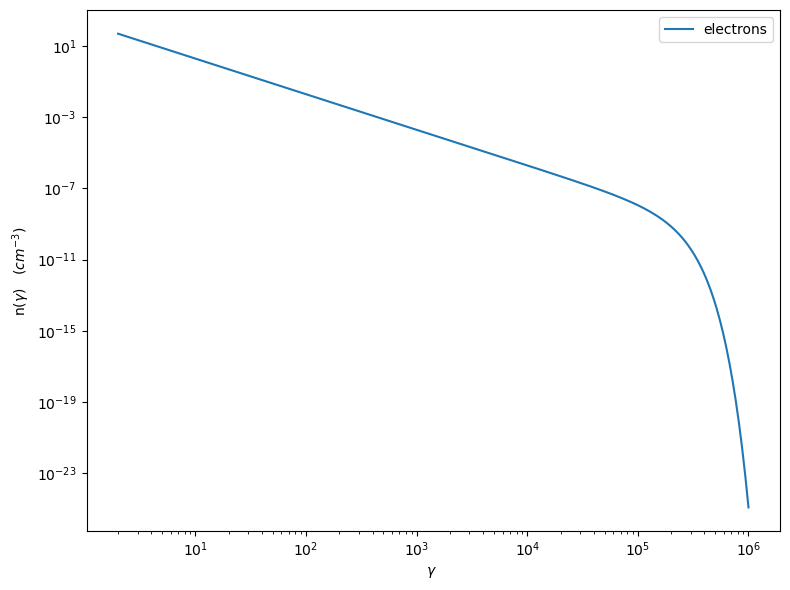

In [6]:
p=n_e_super_exp.plot()


# 場合分け実装テスト

```
def distr_func_super_exp2(gamma,gamma_cut,s,a,br):
    if gamma < 1000. : 
        return np.power(gamma,-s + 1)
    else:
        return np.power(gamma,-s)*np.exp(-(1/a)*(gamma/gamma_cut)**a)

```
これをやるとエラーになる
```
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
```        

## 解決法:
np.peacewise
https://misaki-yuyyuyu.hatenablog.com/entry/2017/06/01/173332


In [7]:
def distr_func_super_exp2(gamma,gamma_cut,s,a,br):
    condlist = [gamma <=1000 , gamma >1000]
    funclist = [lambda gamma: np.power(gamma,-s + 1), lambda gamma: np.power(gamma,-s)*np.exp(-(1/a)*(gamma/gamma_cut)**a) ]
    return np.piecewise(gamma, condlist, funclist)

In [8]:
n_e_super_exp2=EmittersDistribution('super_exp',spectral_type='user_defined')
n_e_super_exp2.add_par('gamma_cut',par_type='turn-over-energy',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_super_exp2.add_par('s',par_type='LE_spectral_slope',val=2.3,vmin=-10., vmax=10, unit='')
n_e_super_exp2.add_par('a',par_type='spectral_curvature',val=1.8,vmin=0., vmax=100., unit='')
n_e_super_exp2.add_par('br',par_type='spectral_break',val=1e3,vmin=0., vmax=None, unit='')
n_e_super_exp2.set_distr_func(distr_func_super_exp2)

In [9]:
n_e_super_exp2.set_distr_func(distr_func_super_exp2)
n_e_super_exp2.parameters.s.val=.4
n_e_super_exp2.parameters.s.val=2.0
n_e_super_exp2.parameters.br.val=1e3
n_e_super_exp2.parameters.gamma_cut.val=1E5
n_e_super_exp2.normalize=True
n_e_super_exp2.parameters.gmax.val=1E6

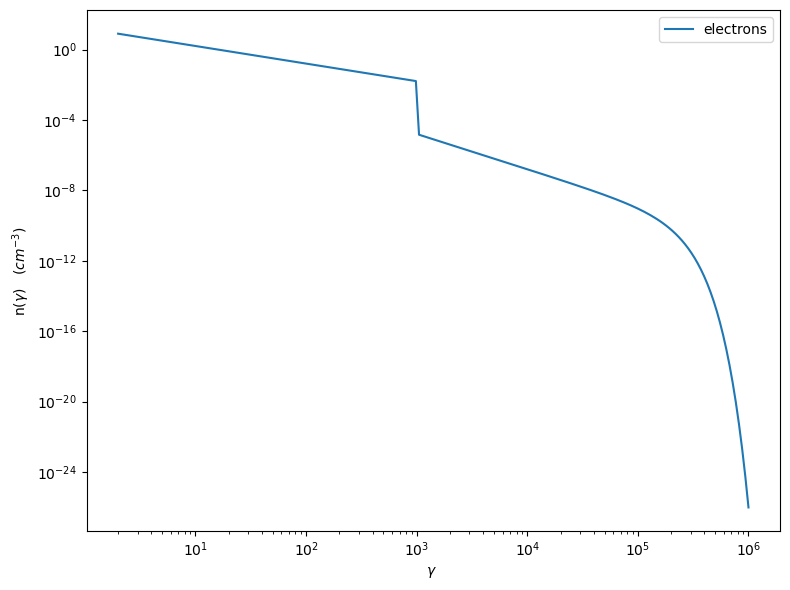

In [10]:
p=n_e_super_exp2.plot()

In [25]:
  
def dist_func_pileup(gamma,gamma_inj,gamma_0,gamma_eq,s,r,K):
  condlist = [gamma <gamma_inj ,  (gamma >= gamma_inj) & (gamma < gamma_0) ,  (gamma >= gamma_0) & (gamma < gamma_eq), gamma >= gamma_eq]
  funclist = [lambda gamma: 0.0, lambda gamma: np.power(gamma/gamma_0,-s), lambda gamma: np.power(gamma/gamma_0,-s+r*np.log(gamma/gamma_0)),lambda gamma:  K*gamma*gamma*np.exp(-gamma/gamma_eq)]
  return np.piecewise(gamma, condlist, funclist)

In [26]:
n_e_pileup=EmittersDistribution('pileup',spectral_type='user_defined')
n_e_pileup.add_par('gamma_inj',par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gamma_0',  par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gamma_eq', par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')

n_e_pileup.add_par('s',par_type='LE_spectral_slope',val=1.0,vmin=-10., vmax=10, unit='')
n_e_pileup.add_par('r',par_type='spectral_curvature',val=6.0,vmin=0., vmax=100., unit='')
n_e_pileup.add_par('K',par_type='scaling_factor',val=1e-17,vmin=0., vmax=None, unit='')
n_e_pileup.set_distr_func(dist_func_pileup)

```
Parameter Slow cooling Fast cooling
R [cm] 8.8 × 1015 3.3 × 1015
B [G] 0.10 0.30
N [cm−3] 0.54 2.50
δ 10.00 10.00
γmax 1.00 × 107 1.00 × 107
γinj 1.00 × 104 5.00 × 103
γ0 1.50 × 105 1.30 × 105
s 1.27 1.28
r 6.00 6.10
K 5.30 × 10−17 7.00 × 10−18
γeq 4.05 × 105 4.0 × 105
```

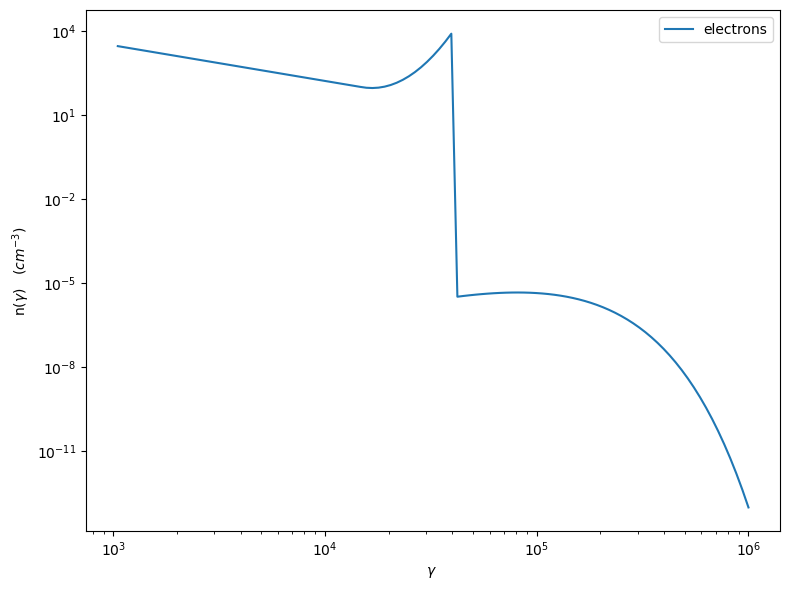

In [28]:
n_e_pileup.parameters.gamma_inj.val=1.0e3
n_e_pileup.parameters.gamma_0.val  =1.5e4
n_e_pileup.parameters.gamma_eq.val  =4.05e4
n_e_pileup.parameters.s.val=1.27
n_e_pileup.parameters.r.val=6.00
# n_e_pileup.parameters.r.val=1.5
n_e_pileup.parameters.K.val=5.30e-17
# n_e_pileup.parameters.K.val=2.0e-11
p=n_e_pileup.plot()

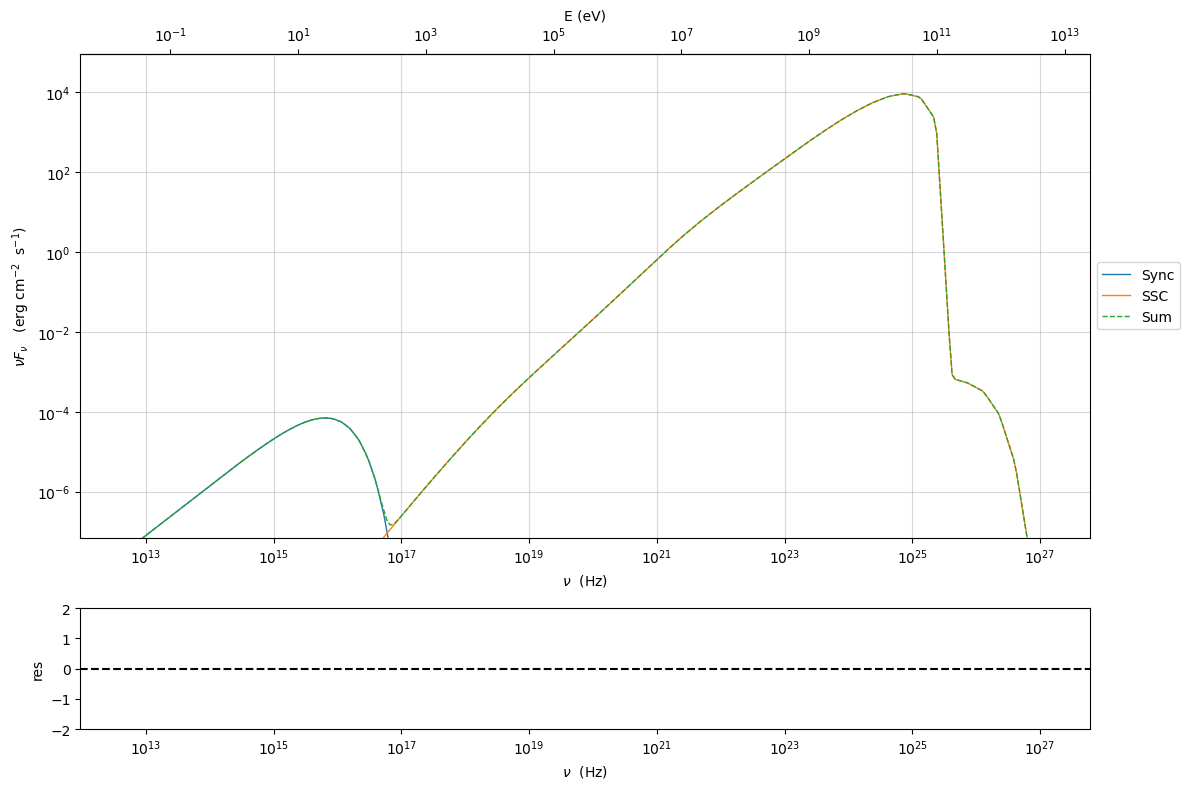

In [29]:
from jetset.jet_model import Jet
jet_pileup = Jet(emitters_distribution=n_e_pileup, verbose=False)

jet_pileup.eval()
p=jet_pileup.plot_model()


In [30]:
jet_pileup.show_model()


--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  

electrons distribution:
 type: pileup  
 gamma energy grid size:  201
 gmin grid : 2.000000e+00
 gmax grid : 1.000000e+06
 normalization:  False
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e-01

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sync, state: self-abs
   name:SSC, state: on
external fields transformation method: blob

SED info:
 nu grid size jetkernel: 1000
 nu size: 500
 nu mix (Hz): 1.000000e+06
 nu max (Hz): 1.000000e+30

flux plot lower bound   :  1.000000e-30

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,lorentz-factor*,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.000000e+02,0.000000e+00,--,False,False
jet_leptonic,gamma_inj,gamma_grid,lorentz-factor*,1.000000e+03,1.000000e+00,--,False,False


--------------------------------------------------------------------------------


```
Parameter Slow cooling Fast cooling
R [cm] 8.8 × 10^15 3.3 × 10^15
B [G] 0.10 0.30
N [cm−3] 0.54 2.50
δ 10.00 10.00
γmax 1.00 × 10^7 1.00 × 10^7
γinj 1.00 × 10^4 5.00 × 10^3
γ0 1.50 × 10^5 1.30 × 10^5
s 1.27 1.28
r 6.00 6.10
K 5.30 × 10^−17 7.00 × 10^−18
γeq 4.05 × 10^5 4.0 × 10^5
```

In [31]:
jet_pileup.set_par('z_cosm',0.034)
jet_pileup.set_par('R',8.8e15)

jet_pileup.set_par('R_H',8.8e15)
jet_pileup.set_par('N',0.54)
jet_pileup.set_par('gmin',1.0e3)
jet_pileup.set_par('gmax',1.0e7)
jet_pileup.show_model()


--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  

electrons distribution:
 type: pileup  
 gamma energy grid size:  201
 gmin grid : 2.000000e+00
 gmax grid : 1.000000e+06
 normalization:  False
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e-01

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sync, state: self-abs
   name:SSC, state: on
external fields transformation method: blob

SED info:
 nu grid size jetkernel: 1000
 nu size: 500
 nu mix (Hz): 1.000000e+06
 nu max (Hz): 1.000000e+30

flux plot lower bound   :  1.000000e-30

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,8.800000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,8.800000e+15,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,lorentz-factor*,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.400000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+07,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,5.400000e-01,0.000000e+00,--,False,False
jet_leptonic,gamma_inj,gamma_grid,lorentz-factor*,1.000000e+03,1.000000e+00,--,False,False


--------------------------------------------------------------------------------


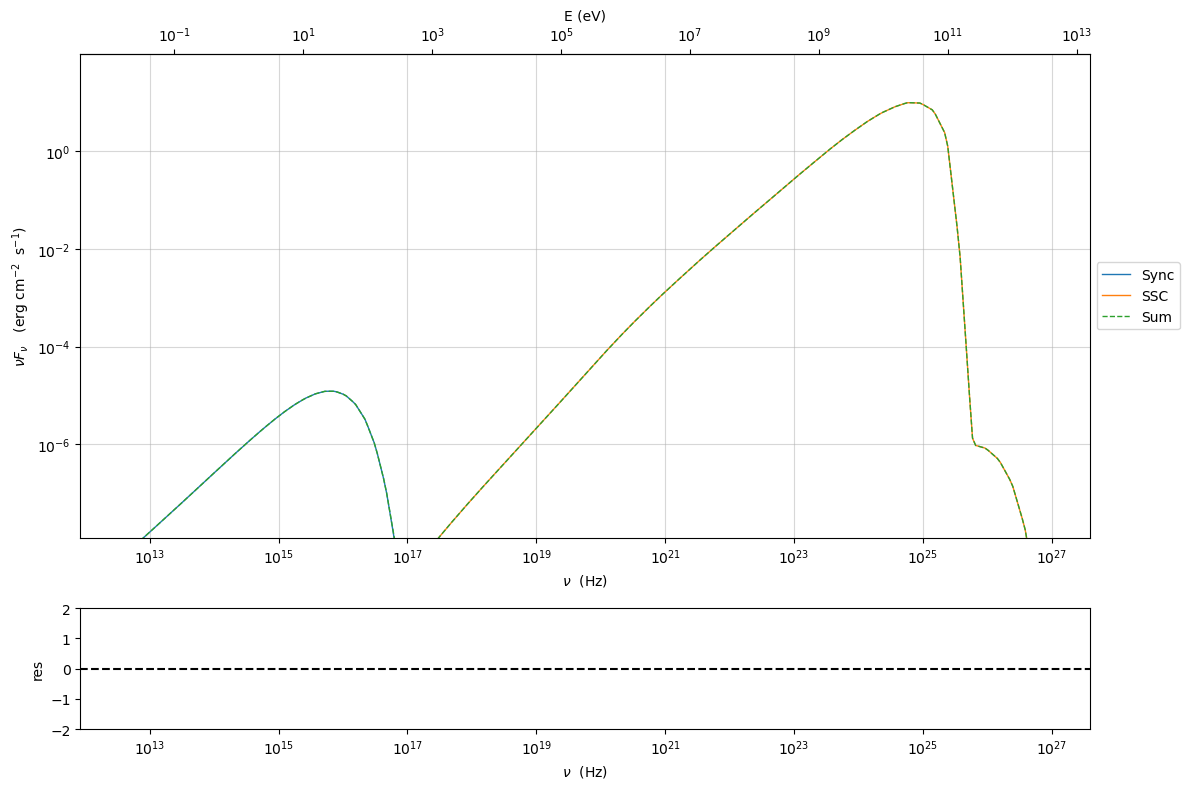

In [32]:
jet_pileup.eval()
p=jet_pileup.plot_model()


In [18]:
def dist_func_pileup_smooth(gamma, gamma_inj, gamma_0, gamma_eq, s, r):
    gamma = np.asarray(gamma)

    # define pieces
    f3_eq = np.power(gamma_eq/gamma_0, -s + r*np.log(gamma_eq/gamma_0))
    K = f3_eq / (gamma_eq**2 * np.exp(-1))  # ensures continuity at gamma_eq

    condlist = [
        gamma < gamma_inj,
        (gamma >= gamma_inj) & (gamma < gamma_0),
        (gamma >= gamma_0) & (gamma < gamma_eq),
        gamma >= gamma_eq
    ]

    funclist = [
        lambda gamma: 0.0,
        lambda gamma: np.power(gamma/gamma_0, -s),
        lambda gamma: np.power(gamma/gamma_0, -s + r*np.log(gamma/gamma_0)),
        lambda gamma: K * gamma**2 * np.exp(-gamma/gamma_eq)
    ]

    return np.piecewise(gamma, condlist, funclist)

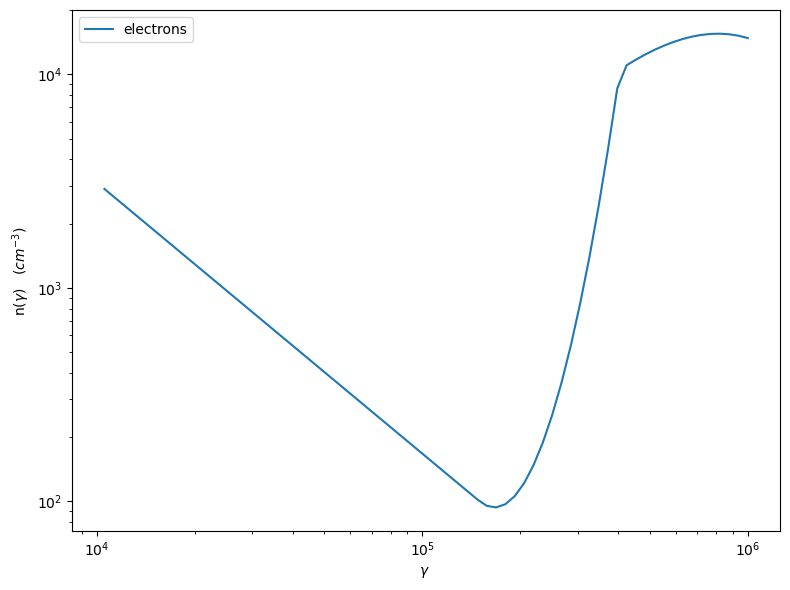

In [19]:
n_e_pileup=EmittersDistribution('pileup',spectral_type='user_defined')
n_e_pileup.add_par('gamma_inj',par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gamma_0',  par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gamma_eq', par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')

n_e_pileup.add_par('s',par_type='LE_spectral_slope',val=1.0,vmin=-10., vmax=10, unit='')
n_e_pileup.add_par('r',par_type='spectral_curvature',val=6.0,vmin=0., vmax=100., unit='')
# n_e_pileup.add_par('K',par_type='scaling_factor',val=1e-17,vmin=0., vmax=None, unit='')
n_e_pileup.set_distr_func(dist_func_pileup_smooth)
n_e_pileup.parameters.gamma_inj.val=1.0e4
n_e_pileup.parameters.gamma_0.val  =1.5e5
n_e_pileup.parameters.gamma_eq.val  =4.05e5
n_e_pileup.parameters.s.val=1.27
n_e_pileup.parameters.r.val=6.00
# n_e_pileup.parameters.K.val=5.30e-17
p=n_e_pileup.plot()